# Plan 4 exponentially discounted risk control

This notebook reads immutable Phase 6 artifacts. The five schedules share one outer development replica, so schedule-averaged differences are descriptive rather than independent-replica inference. NLL is the predeclared primary predictive outcome.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'mnist_experiment' else Path.cwd()
SCREEN = ROOT / 'cache/mnist_experiment/plan4/edr/screen/edr_screen__014849bf996e'
ANALYSIS = ROOT / 'cache/mnist_experiment/plan4/edr/analysis/edr_predictive__f83d7cbf0459'
for artifact in (SCREEN, ANALYSIS):
    if not (artifact / 'COMPLETED').is_file():
        raise FileNotFoundError(f'completed Phase 6 artifact is required: {artifact}')
SCREEN_SUMMARY = json.loads((SCREEN / 'summary.json').read_text(encoding='utf-8'))
SUMMARY = json.loads((ANALYSIS / 'summary.json').read_text(encoding='utf-8'))
print(SUMMARY['interpretation_gate'])

{'all_schedule_full_nll_differences_worse': True, 'authorizes_fresh_replica_confirmation': False, 'basis': 'predictive_underperformance_vs_fixed_0025', 'classification': 'failure', 'edr_minus_fixed_0025_schedule_mean_full_nll': 1.4475040784547804, 'floor_driven': False, 'post_cold_floor_fractions': {'linear': 0.0, 'logistic-k128': 0.0, 'logistic-k256': 0.0, 'logistic-k32': 0.0, 'logistic-k64': 0.0}, 'schedule_full_nll_differences': {'linear': 1.875465992819786, 'logistic-k128': 1.9457846138515473, 'logistic-k256': 1.807611983036041, 'logistic-k32': 0.464473188369751, 'logistic-k64': 1.1441846141967773}}


## Artifact-only smoothing screen

Filtering the stored predictable risk coefficients attenuated the raw action variation while retaining an event response. This was an assumption check only: it did not alter learner parameters, Fisher summaries, or later controller states.

In [2]:
screen_rows = []
for schedule, result in SCREEN_SUMMARY['schedules'].items():
    primary = result['filters']['h04-floor010']
    screen_rows.append({
        'schedule': schedule,
        'mean pi': primary['applied_pi_mean'],
        'maximum pi': primary['applied_pi_max'],
        'variation / raw': primary['total_variation_ratio_vs_raw'],
        'event response / raw': primary['event_response_ratio_vs_raw'],
        'peak delay': primary['event_peak_delay_steps_vs_raw'],
        'post-cold floor fraction': primary['post_cold_floor_fraction'],
    })
pd.DataFrame(screen_rows).set_index('schedule').style.format('{:.3f}')

,mean pi,maximum pi,variation / raw,event response / raw,peak delay,post-cold floor fraction
schedule,,,,,,
linear,0.054,0.135,0.405,0.882,8.000,0.000
logistic-k128,0.062,0.145,0.277,0.404,6.000,0.000
logistic-k256,0.065,0.279,0.626,0.975,1.000,0.000
logistic-k32,0.044,0.078,0.210,0.360,10.000,0.000
logistic-k64,0.052,0.115,0.252,0.200,2.000,0.000


## Closed-loop action behavior

The EDR policy smooths the predictable Fisher-risk coefficients with a four-accepted-update half-life. The dashed proposal is the unsmoothed minimizer evaluated at the EDR learner's current state; it is a diagnostic, not the completed raw-adaptive treatment trajectory.

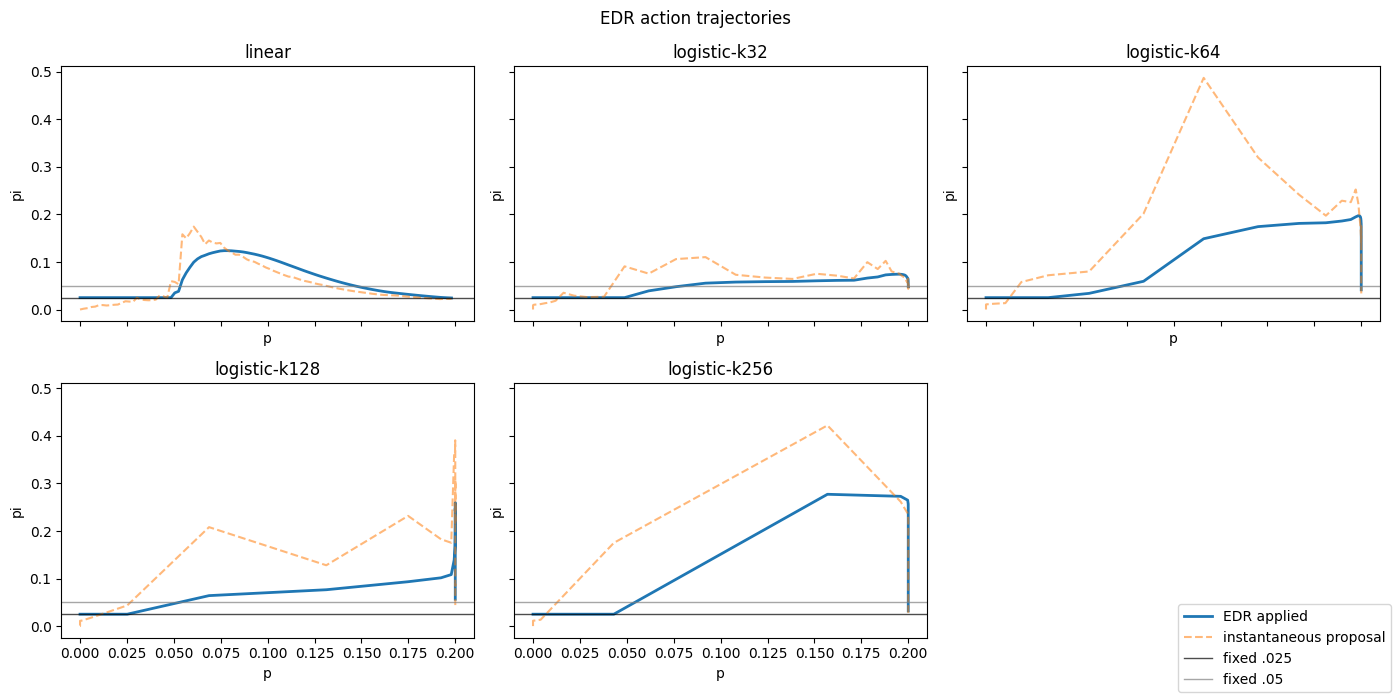

In [3]:
schedule_order = ['linear', 'logistic-k32', 'logistic-k64', 'logistic-k128', 'logistic-k256']
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)
for axis, schedule in zip(axes.flat, schedule_order):
    rows = SUMMARY['schedules'][schedule]['conditions']['edr-fisher-pimin001-h04']['controller']['trajectory']
    p = np.asarray([row['p'] for row in rows])
    axis.plot(p, [row['applied_pi'] for row in rows], label='EDR applied', linewidth=2)
    axis.plot(p, [row['instantaneous_plugin_pi'] for row in rows], label='instantaneous proposal', alpha=.55, linestyle='--')
    axis.axhline(.025, color='black', linewidth=1, alpha=.7, label='fixed .025')
    axis.axhline(.05, color='gray', linewidth=1, alpha=.7, label='fixed .05')
    axis.set_title(schedule)
    axis.set_xlabel('p')
    axis.set_ylabel('pi')
axes.flat[-1].axis('off')
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right')
fig.suptitle('EDR action trajectories')
fig.tight_layout()

## Primary predictive comparison

Positive NLL differences are worse. EDR underperforms fixed $\pi=.025$ on every schedule, satisfying the predeclared failure gate. Its occasional improvement over the raw controller shows that coefficient smoothing removes some action noise, but not enough to make the Fisher-risk policy operationally competitive.

In [4]:
comparison_rows = []
for schedule in schedule_order:
    result = SUMMARY['schedules'][schedule]
    controller = result['conditions']['edr-fisher-pimin001-h04']['controller']
    comparison_rows.append({
        'schedule': schedule,
        'mean applied pi': controller['full_applied_pi_mean'],
        'maximum pi': controller['full_applied_pi_max'],
        'floor fraction': controller['post_cold_lower_bound_fraction'],
        'zero-risk fallbacks': controller['zero_denominator_fallback_count'],
        'NLL vs fixed .025': result['comparisons']['edr_minus_fixed_0025']['nll']['full_mean_difference'],
        'NLL vs fixed .05': result['comparisons']['edr_minus_fixed_005']['nll']['full_mean_difference'],
        'NLL vs raw adaptive': result['comparisons']['edr_minus_raw_adaptive']['nll']['full_mean_difference'],
    })
comparison_table = pd.DataFrame(comparison_rows).set_index('schedule')
comparison_table.style.format('{:.3f}')

,mean applied pi,maximum pi,floor fraction,zero-risk fallbacks,NLL vs fixed .025,NLL vs fixed .05,NLL vs raw adaptive
schedule,,,,,,,
linear,0.060,0.124,0.000,1.000,1.875,0.450,-1.189
logistic-k32,0.043,0.074,0.000,1.000,0.464,-1.114,-0.510
logistic-k64,0.072,0.197,0.000,1.000,1.144,-0.366,-0.132
logistic-k128,0.088,0.260,0.000,21.000,1.946,0.267,0.664
logistic-k256,0.067,0.277,0.000,35.000,1.808,0.375,0.464


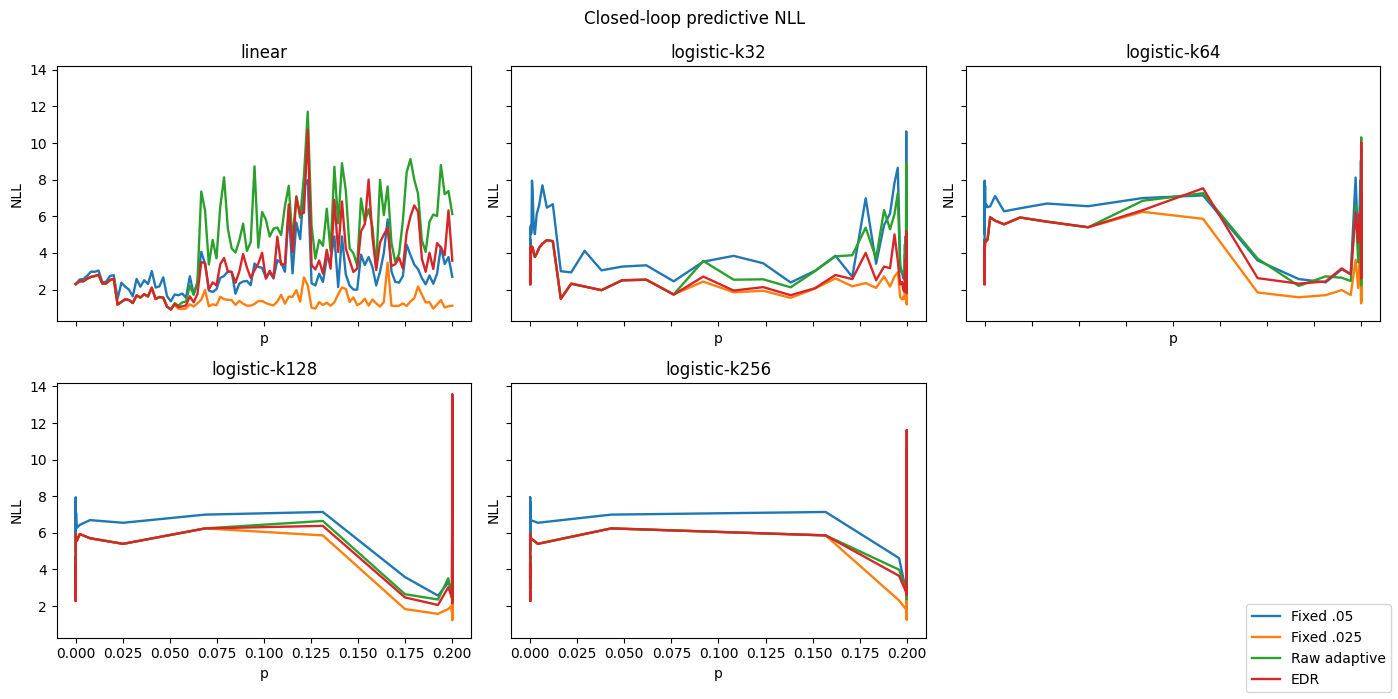

In [5]:
labels = {
    'fixed-pi005': 'Fixed .05',
    'fixed-pi0025': 'Fixed .025',
    'adaptive-fisher-pimin0025-h005': 'Raw adaptive',
    'edr-fisher-pimin001-h04': 'EDR',
}
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)
for axis, schedule in zip(axes.flat, schedule_order):
    for condition, label in labels.items():
        rows = SUMMARY['schedules'][schedule]['conditions'][condition]['predictive_trajectory']
        axis.plot([row['p'] for row in rows], [row['nll'] for row in rows], label=label, linewidth=1.7)
    axis.set_title(schedule)
    axis.set_xlabel('p')
    axis.set_ylabel('NLL')
axes.flat[-1].axis('off')
handles, legend_labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc='lower right')
fig.suptitle('Closed-loop predictive NLL')
fig.tight_layout()

## Secondary predictive context

The table reports EDR minus each fixed policy, averaged over schedules and complete trajectories. Positive values favor EDR for accuracies and recall; negative values favor EDR for NLL and ECE. These are descriptive secondary outcomes from one outer replica.

In [6]:
metrics = ['environment_accuracy', 'nine_ovr_accuracy', 'nine_precision', 'nine_recall', 'non_nine_accuracy', 'nll', 'expected_calibration_error']
aggregate = SUMMARY['aggregate_descriptive_comparisons']
secondary = pd.DataFrame({
    'EDR - fixed .025': {metric: aggregate['edr_minus_fixed_0025'][metric]['schedule_mean_full_difference'] for metric in metrics},
    'EDR - fixed .05': {metric: aggregate['edr_minus_fixed_005'][metric]['schedule_mean_full_difference'] for metric in metrics},
    'EDR - raw adaptive': {metric: aggregate['edr_minus_raw_adaptive'][metric]['schedule_mean_full_difference'] for metric in metrics},
})
secondary.style.format('{:+.3f}')

,EDR - fixed .025,EDR - fixed .05,EDR - raw adaptive
environment_accuracy,-0.029,+0.009,+0.005
nine_ovr_accuracy,-0.008,-0.001,+0.001
nine_precision,-0.028,+0.025,+0.015
nine_recall,-0.016,+0.010,+0.011
non_nine_accuracy,-0.032,+0.004,+0.004
nll,+1.448,-0.078,-0.140
expected_calibration_error,+0.065,-0.025,-0.008


## Original Phase 6 decision

The original EDR condition is a predictive failure, not a floor-driven failure. Its cold start already used the empirically strong fixed $\pi=.025$, so this comparison answers deployment value but not whether EDR could discover a lower operating region from the historical fixed $\pi=.05$.

## Cold-start discovery amendment

This paired linear treatment changes only EDR's cold-start and exact-zero fallback action from $.025$ to $.05$. Fixed $.05$ is the primary comparator; fixed $.025$ is shown only as a hindsight benchmark.

In [ ]:
DISCOVERY = ROOT / 'cache/mnist_experiment/plan4/edr/discovery/analysis/edr_discovery__7b14c111ed7b'
if not (DISCOVERY / 'COMPLETED').is_file():
    raise FileNotFoundError(f'completed EDR discovery artifact is required: {DISCOVERY}')
DISCOVERY_SUMMARY = json.loads((DISCOVERY / 'summary.json').read_text(encoding='utf-8'))
print({
    'cold-prefix parity': DISCOVERY_SUMMARY['cold_prefix_parameter_parity_with_fixed_005'],
    **DISCOVERY_SUMMARY['interpretation_gate'],
})

In [ ]:
new_name = 'edr-fisher-pimin001-h04-cold005'
old_name = 'edr-fisher-pimin001-h04'
new_action = DISCOVERY_SUMMARY['conditions'][new_name]['controller']['trajectory']
old_action = SUMMARY['schedules']['linear']['conditions'][old_name]['controller']['trajectory']
fig, axis = plt.subplots(figsize=(10, 4.5))
axis.plot([row['p'] for row in new_action], [row['applied_pi'] for row in new_action], linewidth=2.2, label='EDR, cold .05')
axis.plot([row['p'] for row in old_action], [row['applied_pi'] for row in old_action], linewidth=1.7, alpha=.75, label='EDR, cold .025')
axis.axhline(.05, color='gray', linewidth=1, label='fixed .05')
axis.axhline(.025, color='black', linewidth=1, label='fixed .025 hindsight')
axis.set(xlabel='p', ylabel='pi', title='Linear EDR cold-start sensitivity')
axis.legend()
fig.tight_layout()

### Cold and live predictive differences

The cold prefix is exactly identical to fixed $.05$, including parameter hashes and predictive outcomes. The live column therefore isolates outcomes after EDR begins choosing its own action. Positive values favor EDR for classification metrics; negative values favor EDR for NLL and ECE.

In [ ]:
discovery_comparison = DISCOVERY_SUMMARY['comparisons']['discovery_minus_fixed_005']
discovery_table = pd.DataFrame({
    'cold EDR - fixed .05': {metric: discovery_comparison['cold'][metric]['mean_difference'] for metric in metrics},
    'live EDR - fixed .05': {metric: discovery_comparison['live'][metric]['mean_difference'] for metric in metrics},
    'full EDR - fixed .05': {metric: discovery_comparison['full'][metric]['full_mean_difference'] for metric in metrics},
})
discovery_table.style.format('{:+.3f}')

In [ ]:
linear_conditions = {
    'fixed-pi005': 'Fixed .05',
    new_name: 'EDR, cold .05',
    old_name: 'EDR, cold .025',
    'fixed-pi0025': 'Fixed .025 hindsight',
}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
for condition, label in linear_conditions.items():
    rows = DISCOVERY_SUMMARY['conditions'][condition]['predictive_trajectory']
    axes[0].plot([row['p'] for row in rows], [row['nll'] for row in rows], label=label)
    axes[1].plot([row['p'] for row in rows], [row['environment_accuracy'] for row in rows], label=label)
axes[0].set(xlabel='p', ylabel='NLL', title='NLL, lower is better')
axes[1].set(xlabel='p', ylabel='environmental accuracy', title='Environmental accuracy')
axes[1].legend()
fig.tight_layout()

## Amended decision

EDR demonstrates **mechanical discovery**: despite starting at $.05$, its final ten unclipped actions average $.02501$. It does not demonstrate **predictive discovery**. After control becomes live, NLL is $1.49$ higher and environmental accuracy is $4.25$ percentage points lower than fixed $.05$, with material regressions in most secondary outcomes. The signal identifies a plausible operating level, but its transient actions and closed-loop path do not improve this learner.